# Linear Regression on Network Traffic

In this hands-on assignment, we will explore learn models, in particular linear regression. Linear models can work well when there is a linear relationship between the target variable being predicted and the input features. In other words, when the target prediction can be modeled as a linear combination of the input features, linear models may be appropriate.

We'll explore the relationship beween bytes and packets in this hands-on, which may have a linear relationship at times. We will also explore how basis expansion---in particular polynomial basis expansion---can allow linear regression to fit more complex relationships between features and targets.

In [1]:
# Machine Learning Libraries
import numpy as np
import pandas as pd
from sklearn import linear_model

import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

# Plotting Library
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)


## Part 1: Simple Linear Regression.

### Group Traffic Info Flows 

This example below uses a packet capture that is provided in the repository. You are also welcome (and encouraged!) to capture your own traffic.

Use `netml` to load the pcap and convert packets to flows, using pcap2flows.

In [2]:
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10)
hpcap.pcap2flows()
len(hpcap.flows)

pcap_file: data/http.pcap
ith_packets: 0
ith_packets: 10000
ith_packets: 20000
len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.


291

### Generate Features

Use the `netml` "STATS" option to generate features for each flow, which will provide the following features for each flow:

0. Duration
1. Packets per second
2. Bytes per second
3. Mean packet size
4. Standard deviation of packet sizes
5. 25th, median, 75th, min, max packet sizes

The exercise below requires a [slight modification](https://github.com/chicago-cdac/netml/pull/16/commits/79c0f930f2882c7bf042a9eb45e2a6ac413a695d) to the `netml` library (for versions <= 0.2.1) to add two additional features:
* number of packets per flow
* number of bytes per flow

You can modify the library (line 455 of `parser.py`) to add total number of packets and bytes per flow, or optionally explore the relationships between some of the other features.

In [3]:
hpcap.flow2features('STATS', fft=False, header=False)

# netml stores the result as a plain numpy array; name the columns so we can read it.
stats_cols = ['duration', 'pkts_rate', 'bytes_rate', 'mean', 'std',
              'q1', 'q2', 'q3', 'min', 'max', 'num_pkts', 'num_bytes']

df = pd.DataFrame(hpcap.features, columns=stats_cols)
print(df.shape)
df.head()

True
(291, 12)


,duration,pkts_rate,bytes_rate,mean,std,q1,q2,q3,min,max,num_pkts,num_bytes
0,30.076,0.133,11.637,87.500,21.500,66.000,87.500,109.000,66.000,109.000,4.000,350.000
1,30.060,0.133,11.444,86.000,20.000,66.000,86.000,106.000,66.000,106.000,4.000,344.000
2,40.960,0.122,8.057,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000
3,40.962,0.122,8.056,66.000,0.000,66.000,66.000,66.000,66.000,66.000,5.000,330.000
4,0.058,34.661,2738.204,79.000,13.000,72.500,79.000,85.500,66.000,92.000,2.000,158.000


### Train Model

Explore the relationship between some of these features. A natural one to explore is the relationship between the number of bytes in a flow and the number of packets in a flow.

X shape: (291, 1)  y shape: (291,)


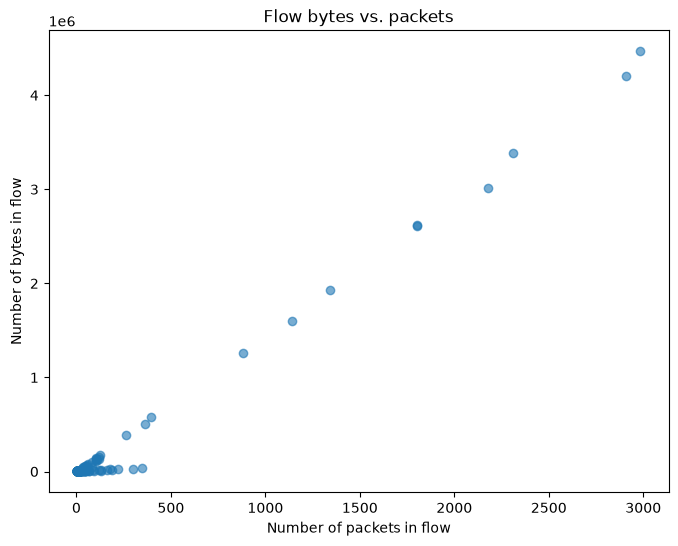

In [10]:
# Feature (what we look at) and target (what we predict).
# X must be 2-D: 291 rows x 1 column. y stays 1-D.
X = df['num_pkts'].values.reshape(-1, 1)
y = df['num_bytes'].values

print('X shape:', X.shape, ' y shape:', y.shape)

# Look at the raw data before fitting anything.
plt.scatter(X, y, alpha=0.6)
plt.xlabel('Number of packets in flow')
plt.ylabel('Number of bytes in flow')
plt.title('Flow bytes vs. packets')
plt.show()

Train a `Linear Regression` model from scikit learn to model this relationship, and output the resulting predictions into a vector `y_hat`.

In [12]:
reg = linear_model.LinearRegression()
reg.fit(X, y)           # solve for the best-fitting line
y_hat = reg.predict(X)  # the model's guess for each flow

print('slope (w):     %.2f bytes per packet' % reg.coef_[0])
print('intercept (b): %.2f bytes' % reg.intercept_)

slope (w):     1447.22 bytes per packet
intercept (b): -21680.35 bytes


### Visualize Your Model

Plot the relationship that your model has learned, by plotting the learned model (which should be a line), along with the points.  Label your axes!

What do you notice about the relationship, and how it relates to the original points?

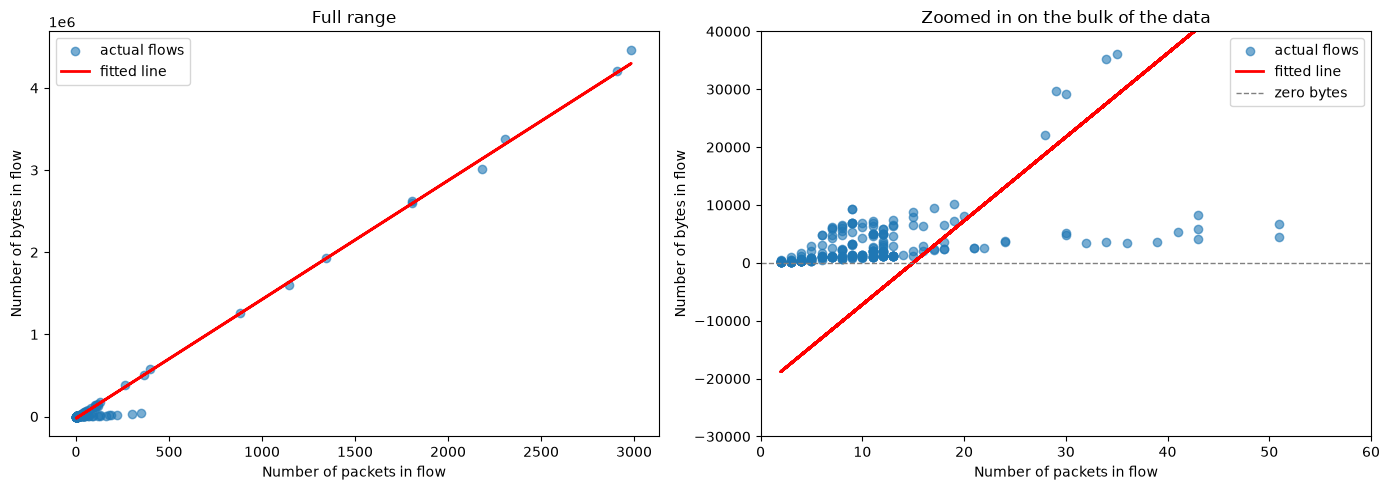

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: the full range, where the big bulk-transfer flows live.
ax1.scatter(X, y, alpha=0.6, label='actual flows')
ax1.plot(X, y_hat, color='red', linewidth=2, label='fitted line')
ax1.set_xlabel('Number of packets in flow')
ax1.set_ylabel('Number of bytes in flow')
ax1.set_title('Full range')
ax1.legend()

# Right: zoom in on where most of the flows actually are.
ax2.scatter(X, y, alpha=0.6, label='actual flows')
ax2.plot(X, y_hat, color='red', linewidth=2, label='fitted line')
ax2.axhline(0, color='gray', linestyle='--', linewidth=1, label='zero bytes')
ax2.set_xlim(0, 60)
ax2.set_ylim(-30000, 40000)
ax2.set_xlabel('Number of packets in flow')
ax2.set_ylabel('Number of bytes in flow')
ax2.set_title('Zoomed in on the bulk of the data')
ax2.legend()

plt.tight_layout()
plt.show()

### Evaluation: Error Computation

You can compute how well your manual fit is by computing the error, in terms of residual sum of squares.

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

residuals = y - y_hat          # truth minus guess, one per flow
rss = np.sum(residuals ** 2)   # the quantity .fit() minimized
mse = rss / len(y)
rmse = np.sqrt(mse)

print('RSS  : %.4e' % rss)
print('MSE  : %.4e' % mse)
print('RMSE : %.0f bytes' % rmse)
print('R^2  : %.4f' % r2_score(y, y_hat))

# sanity check: sklearn agrees with our by-hand MSE
print('\nsklearn MSE matches:', np.isclose(mse, mean_squared_error(y, y_hat)))

# how does the model do on a typical flow?
mid = int(np.median(X))
print('\nA flow with %d packets:' % mid)
print('  predicted: %.0f bytes' % reg.predict([[mid]])[0])
print('  actual median for all flows: %.0f bytes' % np.median(y))

RSS  : 7.5652e+11
MSE  : 2.5997e+09
RMSE : 50987 bytes
R^2  : 0.9903

sklearn MSE matches: True

A flow with 11 packets:
  predicted: -5761 bytes
  actual median for all flows: 2053 bytes


## Part 2: Polynomial Basis Expansion

Recall that one of the benefits of a polynomial feature expansion is that it is possible to fit a linear model to a resulting polynomial expansion of the features.

We will do that below.  Let's first create the regular features and then the polynomial expansion. You will need the `PolynomialFeatures` library from `sklearn.preprocessing`, as well as the `fit_transform` function to generate your feature expansion.

In [15]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

print('X shape     :', X.shape)
print('X_poly shape:', X_poly.shape)
print('columns     :', poly.get_feature_names_out(['num_pkts']))

# First 3 flows, before and after the expansion.
print('\nbefore:\n', X[:3])
print('\nafter (1, x, x^2, x^3):\n', X_poly[:3])

X shape     : (291, 1)
X_poly shape: (291, 4)
columns     : ['1' 'num_pkts' 'num_pkts^2' 'num_pkts^3']

before:
 [[4.]
 [4.]
 [5.]]

after (1, x, x^2, x^3):
 [[  1.   4.  16.  64.]
 [  1.   4.  16.  64.]
 [  1.   5.  25. 125.]]


Train the linear regression model on the expanded set of features, and generate a new set of predictions, `y_hat_poly`.

Visualize your results again. What do you notice about the predicted values?

Evaluate your error once again. What happened to overall mean squared error?

## Part 3: Exploring Relationships between Other Features

In the earlier parts of this hands-on, we explored simple relationship between features and outcome variables. You can extend your analysis by exploring other relationships, such as the relationships between one or more of the features already output from `netml`.

## Bonus: Reducing Error on Test Set

In the above example, we used a polynomial basis expansion to reduce the error on the training set. But, we have no test set, so it is difficult to tell whether the model above is overfit to the training data.

In order for us to tell whether this model is a good fit, we need to test it on data that the model has not yet seen. This requires splitting the data into a training set and a test set.

A typical split between training data and test data might be 80% training data, 20% test data. You can also perform this process repeatedly and average the results. This process is called **cross-validation**.

### Part 1

1. Take a packet trace using wireshark and load it into the notebook.
2. Perform a simple linear regression fit and a fit with basis expansion (same as above), comparing errors.

The first two steps are the same as above, but you might try doing this for a larger sample so that your network traffic has more flows (i.e., data points).

### Part 2

3. Use functions from sklearn to split the data into training and testing. (train_test_split, or sklearn's CV function).
4. How does model accuracy compare for different polynomial basis expansions? (n=1, 2, 3, ?) At what point is the model overfit?
5. Can you experiment with a regularization parameter to control or reduce overfitting?